In [1]:
import numpy as np
import pandas as pd

# Decision Boundary Visualization

A simple machine learning project demonstrating:

- Classification using Scikit-learn
- Decision boundary visualization using mlxtend
- Model serialization using pickle

Tools Used:
- Python
- Scikit-learn
- Matplotlib
- mlxtend
- Pickle

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df = df.iloc[:,1:]

In [5]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [6]:
import matplotlib.pyplot as plt

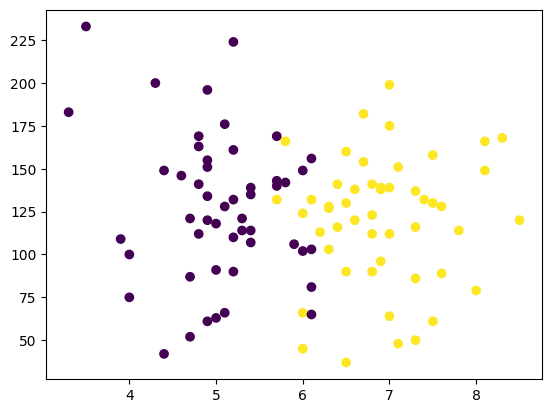

In [8]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [12]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [14]:
x.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [15]:
y.head()

0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64

In [17]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [18]:
x_train

,cgpa,iq
50,3.5,233.0
66,6.9,96.0
71,6.1,132.0
51,4.8,141.0
68,4.0,75.0
...,...,...
60,6.9,139.0
63,6.3,128.0
48,6.6,138.0
87,5.7,132.0


In [19]:
x_test

,cgpa,iq
26,7.0,199.0
81,5.4,107.0
34,4.8,163.0
53,8.3,168.0
12,5.4,139.0
19,5.2,132.0
37,8.1,149.0
16,5.2,224.0
5,7.1,48.0
56,6.1,65.0


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [22]:
x_train = scaler.fit_transform(x_train)

In [23]:
x_train

array([[-2.18681322,  2.94796362],
       [ 0.83424703, -0.68469593],
       [ 0.12340932,  0.26987154],
       [-1.03170195,  0.50851341],
       [-1.74253965, -1.24152695],
       [ 0.6565376 ,  0.85321833],
       [ 0.12340932, -1.08243238],
       [-0.94284724,  0.8797341 ],
       [ 0.47882818, -0.84379051],
       [ 0.74539232, -0.84379051],
       [-0.76513781, -1.48016882],
       [-0.6762831 , -0.31347524],
       [ 0.56768289, -0.04831761],
       [-1.12055666, -0.02180185],
       [-0.23200953,  1.25095478],
       [-0.94284724,  0.77367104],
       [ 0.92310174, -0.26044372],
       [ 1.63393945, -0.20741219],
       [-0.6762831 , -0.84379051],
       [-1.03170195,  1.25095478],
       [-0.85399252, -1.55971611],
       [-0.58742838, -0.20741219],
       [ 0.03455461, -2.03699985],
       [ 0.92310174,  0.45548189],
       [-0.94284724, -1.61274764],
       [ 0.47882818, -2.24912595],
       [ 0.30111875,  0.13729273],
       [ 0.03455461, -0.52560135],
       [ 0.92310174,

In [25]:
x_test = scaler.transform(x_test)

In [26]:
x_test

array([[ 0.92310174,  2.04642768],
       [-0.49857367, -0.39302253],
       [-1.03170195,  1.0918602 ],
       [ 2.07821302,  1.22443902],
       [-0.49857367,  0.45548189],
       [-0.6762831 ,  0.26987154],
       [ 1.90050359,  0.72063952],
       [-0.6762831 ,  2.70932175],
       [ 1.01195646, -1.95745256],
       [ 0.12340932, -1.50668459]])

In [27]:
from sklearn.linear_model import LogisticRegression

In [29]:
clf = LogisticRegression()

# Model Training

In [30]:
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [34]:
y_pred = clf.predict(x_test)

In [33]:
y_test

26    1
81    0
34    0
53    1
12    0
19    0
37    1
16    0
5     1
56    0
Name: placement, dtype: int64

In [35]:
from sklearn.metrics import accuracy_score

In [37]:
accuracy_score(y_test,y_pred)

0.9

In [39]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

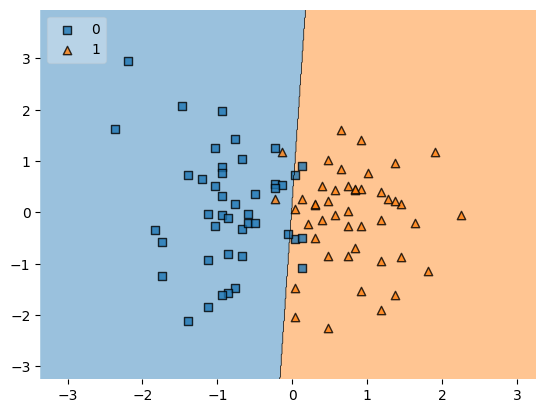

In [40]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [42]:
import pickle

In [43]:
pickle.dump(clf, open('model.pkl','wb'))